**1.- Variables:**

Las variables serán
$x_i$ - El peso de cada tina
$w$ - El peso total de las 5 tinas

**2.- Distribución de probabilidad**

En este caso, se tiene una distribución triangular simétrica. Con:

$a = 190$, $c = 210$, $b =n 230$ $\sqrt{4}$

**3.- Modelado de las variables aleatorias**

Para este caso, usamos la transformada inversa de la distrinución normal. 

$$Si U <= \frac{210 - 190}{230 - 190} = 0.5$$

Entonces $X = 190 + \sqrt{800U}$

$$Si U > \frac{210 - 190}{230 - 190} = 0.5$$

Entonces $X = 230 - \sqrt{800U}$

**4.- Modelo y objetivos**

Modelo: Se generan 5 números aleatorios uniformes y se transforman en el peso de las tinas usando las fórmyulas anteriores. Posteriormente, se suman estos pesos y se determina si son menores o mayores que 1000 
Objetivo: Estimar la probabilidad de que el peso sea mayor que 1000

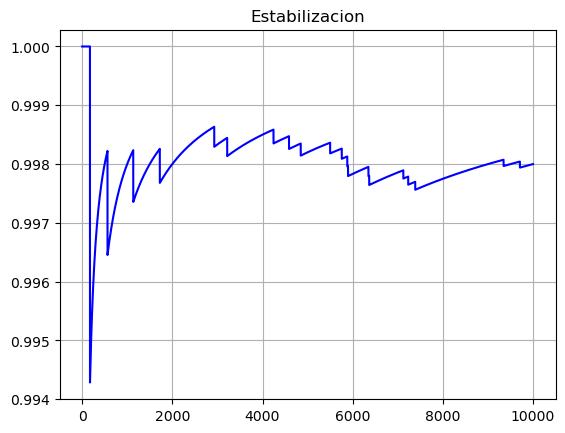

media: 0.9975539999999999
lim inf: 0.9974596770514205
lim sup: 0.9976483229485794


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

tin = 5
cap = 1000
ite = 10000
rep= 100

probs = []

for i in range(rep):
    u = np.random.uniform(0, 1, (ite, tin))
    p = np.zeros((ite, tin))
    
    p[u <= 0.5] = 190 + np.sqrt(800 * u[u <= 0.5])
    p[u > 0.5] = 230 - np.sqrt(800* (1 - u[u > 0.5]))
    
    ptot = np.sum(p, axis=1)
    exc = ptot > cap
    
    prob = np.sum(exc)/ite
    probs.append(prob)
    
    if i == 0:
        p_acu = np.cumsum(exc) / np.arange(1, ite+ 1)
        plt.plot(p_acu, color="blue")
        plt.title('Estabilizacion')
        plt.grid(True)
        plt.show()

g_med = np.mean(probs)
desv = np.std(probs, ddof=1)

z = norm.ppf(0.975) 
err = z * (desv / np.sqrt(rep))

lim_i = g_med - err
lim_s = g_med + err

print("media:", g_med)
print("lim inf:", lim_i)
print("lim sup:", lim_s)